### 7. Trajectories of politicians who change party

In [1]:
#setup
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


## 1. Load


In [2]:
# data files
MP_YEAR   = "mp_year_embeddings_finetuned.parquet"   # one aggregated vector per MP and year
SPEECHES  = "jina_v3_contrastive_full.parquet"       # one row per speech, same encoder

#setup for plots
#coloring
PARTY_COLORS = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "AfD": "royalblue", "PDS": "darkorchid",
                "Fraktionslos": "grey"}
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

mp = pd.read_parquet(MP_YEAR)

# For filtering the MPs who switched party, we only need who spoke when and for which party, so we read those three columns
meta = pd.read_parquet(SPEECHES, columns=["politicianId", "politicianName", "party", "year_month"])

#-1 politican ID =! one person -> drop it
print(f"before dropping politicianId == -1: {mp.politicianId.nunique()} MPs, {len(meta):,} speeches")
mp   = mp[mp.politicianId != -1].copy()
meta = meta[meta.politicianId != -1].copy()
mp["E"] = mp.embedding.map(lambda v: np.asarray(v, dtype="float32"))
meta["ym"] = pd.PeriodIndex(meta.year_month, freq="M")

print(f"after : {mp.politicianId.nunique()} MPs | {len(mp):,} MP-years | {len(meta):,} speeches")
print(f"embedding dim: {len(mp.E.iloc[0])} | years {mp.year.min()}-{mp.year.max()}")
print(f"\nspeeches per MP-year: median {mp.n_speeches.median():.0f}, "
      f"{(mp.n_speeches < 5).mean():.0%} of MP-years have fewer than 5")

before dropping politicianId == -1: 1735 MPs, 82,447 speeches
after : 1735 MPs | 12,458 MP-years | 82,447 speeches
embedding dim: 1024 | years 2000-2021

speeches per MP-year: median 5, 47% of MP-years have fewer than 5


## 2. Who actually changes party?


In [3]:
# Mark where a new spell starts: the party changed, or we moved to a different MP.
# cumsum() then numbers the spells, so one groupby collapses each run of speeches.
m = meta.sort_values(["politicianId", "ym"])
new_spell = (m.party != m.party.shift()) | (m.politicianId != m.politicianId.shift())
spells = (m.assign(spell=new_spell.cumsum())
            .groupby(["spell", "politicianId", "party"], as_index=False)
            .agg(first=("ym", "min"), last=("ym", "max"), n=("ym", "size"))
            .drop(columns="spell"))

# A transition is a spell paired with the MP's previous one, so shift within each MP.
# The first spell of each MP has no predecessor and drops out.
s = spells.sort_values(["politicianId", "first"])
prev = s.groupby("politicianId").shift(1)
events = pd.DataFrame({
    "politicianId": s.politicianId,
    "old_party": prev.party, "new_party": s.party,
    "last_old": prev["last"], "first_new": s["first"],
    # months of silence between the two spells - the column that separates the three groups
    "gap_months": (s["first"].dt.year * 12 + s["first"].dt.month)
                - (prev["last"].dt.year * 12 + prev["last"].dt.month),
    "n_old": prev.n, "n_new": s.n, "switch_year": s["first"].dt.year,
}).dropna(subset=["old_party"]).astype({"n_old": int, "gap_months": int})

print(f"{events.politicianId.nunique()} MPs show a party change "
      f"({len(events)} transitions in total)\n")
print(events.sort_values(["politicianId", "first_new"]).to_string(index=False))

20 MPs show a party change (22 transitions in total)

 politicianId    old_party    new_party last_old first_new  gap_months  n_old  n_new  switch_year
     11000756          PDS        LINKE  2002-01   2005-11          46     38    293         2005
     11000921          PDS        LINKE  2002-06   2005-12          42     52    255         2005
     11001023          PDS        LINKE  2002-05   2005-12          43     39    296         2005
     11001363          SPD Fraktionslos  2001-05   2002-03          10      5      2         2002
     11002153          PDS        LINKE  2002-06   2005-11          41    116    184         2005
     11002636          PDS        LINKE  2002-09   2005-12          39     58    250         2005
     11002701        Grüne        LINKE  2002-06   2005-11          41     27     55         2005
     11002808      CDU/CSU Fraktionslos  2016-11   2017-06           7     70      2         2017
     11002813          SPD Fraktionslos  2009-06   2009-07      

The table falls into three groups.

1. 10 MPs move from PDS to LINKE between 2005 and 2007. That is the merger with the WASG, not a
defection.

2. 2 go PDS → Fraktionslos → LINKE. The PDS fell below five percent in 2002 and kept only
two direct mandates, so these two sat without Fraktion status for a full term.

3. Genuine defections, where an MP leaves the party they were elected for, usually
first to Fraktionslos and sometimes on to another party.

Only 3. group answers our question. We keep the other two as a placebo group.

Note the labels do not map onto these groups one-to-one: the rule only writes `defection` when
an MP moves straight from one party to another, which happens once (Knoche). The others left to
sit as independents first and are filed under `status change`, politically still defections.

In [4]:
#grouping switches to the groups

LINEAGE = {"PDS": "LINKE-bloc", "LINKE": "LINKE-bloc"}   # one party lineage across the merger

kind = []
for _, r in events.iterrows():
    if LINEAGE.get(r.old_party) and LINEAGE.get(r.old_party) == LINEAGE.get(r.new_party):
        kind.append("merger / rename")
    elif "Fraktionslos" in (r.old_party, r.new_party):
      #Fraktionslos at some point
        kind.append("status change")
    else:
      #from one party straight to another party
        kind.append("defection")
events["kind"] = kind

# Someone who goes PDS -> Fraktionslos -> LINKE never actually left the lineage, so the whole
# path should count as a rename even though the middle step looks like a defection.
for pid, g in events.groupby("politicianId"):
    ends = {g.iloc[0].old_party, g.iloc[-1].new_party}
    if len(g) > 1 and len({LINEAGE.get(p, p) for p in ends}) == 1:
        events.loc[g.index, "kind"] = "merger / rename"

# Two counts, because an MP with a multi-step path contributes more than one transition.
#counts transitions
print(events.kind.value_counts().to_string())
print()

#counts people -> gap identifies exactly those MPs: Pau (PDS -> Fraktionslos -> LINKE) is the extra merger row, Hohmann
# (CDU/CSU -> Fraktionslos -> AfD) the extra status-change row.
print("MPs per category:")
print(events.groupby("kind").politicianId.nunique().to_string())

kind
merger / rename    12
status change       9
defection           1

MPs per category:
kind
defection           1
merger / rename    11
status change       8


Selection rule: at least 3 speeches on the thinner side of the switch. Below that an MP-year mean is one or two debates, so it captures the day's agenda rather than the speaker. This is what excludes the other three genuine defections (Lörcher, Steinbach and Bülow, with 2, 2 and 1 speeches after leaving).

In [5]:
# The five defections with enough speech on either side to compare.
#The before/after windows come from the years we actually observe rather than a fixed offset, because most of these
# MPs are missing from parliament for part of the period.
CASES = [
    dict(key="A", pid=11002701, old="Grüne",   new="LINKE",        switch=2005,
         pre=[2000, 2001, 2002], post=[2006, 2007, 2008, 2009]),
    dict(key="B", pid=11003152, old="CDU/CSU", new="AfD",          switch=2018,
         pre=[2000, 2001, 2002, 2003], post=[2018, 2019, 2020]),
    dict(key="C", pid=11002813, old="SPD",     new="Fraktionslos", switch=2009,
         pre=[2006, 2007, 2008], post=[2009]),
    dict(key="D", pid=11003601, old="CDU/CSU", new="Fraktionslos", switch=2007,
         pre=[2003, 2004, 2005], post=[2007, 2008, 2009]),
    dict(key="E", pid=11004772, old="AfD",     new="Fraktionslos", switch=2019,
         pre=[2018], post=[2019]),
]

# names come straight from the speech file, so the tables below are readable
id2name = meta.drop_duplicates("politicianId").set_index("politicianId").politicianName
events["name"] = events.politicianId.map(id2name)
# Attach the name to each case
for c in CASES:
    c["name"] = id2name[c["pid"]].title()
    dest = "independent" if c["new"] == "Fraktionslos" else c["new"]
    c["label"] = f'{c["key"]} · {c["name"]} ({c["old"]} → {dest}, {c["switch"]})'

#MPs that did not have an actual party switch (Linke-Lager)
PLACEBO = events.loc[events.kind == "merger / rename", "politicianId"].unique().tolist()
# 11003584 is the same 2002-05 direct-mandate case, but this corpus only sees them from the
# Fraktionslos spell onward, so the automatic rule has nothing to match on. Added manually.
PLACEBO = sorted(set(PLACEBO) | {11003584})
SWITCHERS = set(events.politicianId) | {c["pid"] for c in CASES}

print(events[["politicianId", "name", "old_party", "new_party", "switch_year", "kind"]]
      .drop_duplicates().to_string(index=False))
print()
print(pd.DataFrame(CASES)[["key", "pid", "name", "old", "new", "switch", "pre", "post"]].to_string(index=False))
print(f"\nplacebo group (label changed, no defection): {len(PLACEBO)} MPs")

 politicianId                 name    old_party    new_party  switch_year            kind
     11000756          gregor gysi          PDS        LINKE         2005 merger / rename
     11000921         Barbara Höll          PDS        LINKE         2005 merger / rename
     11001023          ulla jelpke          PDS        LINKE         2005 merger / rename
     11001363      Christa Lörcher          SPD Fraktionslos         2002   status change
     11002153         Ilja Seifert          PDS        LINKE         2005 merger / rename
     11002636 eva bulling-schröter          PDS        LINKE         2005 merger / rename
     11002701        Monika Knoche        Grüne        LINKE         2005       defection
     11002808      Erika Steinbach      CDU/CSU Fraktionslos         2017   status change
     11002813           jörg tauss          SPD Fraktionslos         2009   status change
     11003034      Dietmar Bartsch          PDS        LINKE         2006 merger / rename
     11003

## 3. Measurement
Choices:

1. *Removing the era effect.* Notebook 06 found all parties drifting together on PC1 from around
2014, meaning parliamentary language changes over time regardless of who is speaking. We
subtract each year's parliament-wide mean vector, which leaves only relative position within
that year. A trajectory can then no longer be produced by the calendar alone.

2. *Anchoring the axis on the two parties involved.* Not PC1, and not the global left–right axis
from notebook 06, which put the AfD next to LINKE. For each case the axis runs from the old
party's centroid to the new party's, computed per year and averaged. It answers one narrow
question: does this MP sound more like where they went, or where they came from?

3. *Leaving the MP out of their own yardstick.* If a switcher helps define the centroid they are
being compared against, part of their apparent position is just themselves.

The score is expressed in units of the old party's own spread,

$$z_{i,y} = \frac{p_{i,y} - \overline{p}_{\text{old},y}}{\mathrm{sd}(p_{\text{old},y})}$$

so $z = 0$ is an average member of the old party in that year and the dotted line in the plots
shows where the new party's members sit. Because both anchors are re-estimated every year, the
years before and after a switch stay comparable even when they are a decade apart.

In [6]:
def cos(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


# Subtract each year's parliament-wide mean vector, i.e. take out the era effect. Ed is the
# column everything downstream works on.
year_mu = {y: np.average(np.stack(g.E.to_numpy()), axis=0,
                         weights=g.n_speeches.to_numpy(dtype="float32"))
           for y, g in mp.groupby("year")}
mpd = mp.assign(Ed=[e - year_mu[y] for e, y in zip(mp.E, mp.year)])


def trajectory(mp_src, pid, old, new, min_speeches=3):
    """One switcher's position over time on the old -> new party axis, in old-party SD units.

    Builds the party centroids without the switcher in them, takes the axis between the two,
    projects everyone onto it, and z-scores within each year against the OLD party. Anchoring
    on the old party (rather than rescaling between the two) means the score still exists in
    years when the new party does not, which is exactly what the pre-switch half needs.
    """
    ref = mp_src[mp_src.politicianId != pid]
    cent = {(p, y): np.average(np.stack(g.Ed.to_numpy()), axis=0,
                               weights=g.n_speeches.to_numpy(dtype="float32"))
            for (p, y), g in ref.groupby(["party", "year"])}

    diffs = [cent[(new, y)] - cent[(old, y)] for (p, y) in cent
             if p == new and (old, y) in cent]
    axis = np.mean(diffs, axis=0)
    axis /= np.linalg.norm(axis)

    d = mp_src.assign(proj=np.stack(mp_src.Ed.to_numpy()) @ axis)
    rows, anchors = [], []
    for y, g in d.groupby("year"):
        r = d[(d.year == y) & (d.politicianId != pid)]
        o, n = r.loc[r.party == old, "proj"], r.loc[r.party == new, "proj"]
        if len(o) < 5 or o.std() == 0:
            continue
        mu, sd = o.mean(), o.std()
        rows.append(g.assign(z=(g.proj - mu) / sd))
        anchors.append(dict(year=y, n_old=len(o), n_new=len(n),
                            z_new=(n.mean() - mu) / sd if len(n) >= 5 else np.nan))
    z, anch = pd.concat(rows), pd.DataFrame(anchors)
    g = z[z.politicianId == pid].sort_values("year").merge(anch, on="year", how="left")
    return g[g.n_speeches >= min_speeches], anch

## 4. Knoche — Grüne → LINKE


In [7]:
# LINKE does not exist before 2005, so the far end of the axis is anchored on the LINKE
# lineage: PDS before the merger, LINKE after. Without it the Green years have no reference.
mp_bloc = mpd.assign(party=mpd.party.replace(LINEAGE))

knoche = CASES[0]
g_knoche, anch_knoche = trajectory(mp_bloc, knoche["pid"], "Grüne", "LINKE-bloc")
print(g_knoche[["year", "party", "n_speeches", "z", "z_new", "n_old", "n_new"]].to_string(index=False))

 year      party  n_speeches         z    z_new  n_old  n_new
 2000      Grüne          12  0.091939 1.411031     44     34
 2001      Grüne           9 -0.148783 1.362003     42     35
 2002      Grüne           6  0.438605 1.147266     53     37
 2006 LINKE-bloc          12  3.036787 1.949697     49     50
 2007 LINKE-bloc          13  2.088390 2.116992     51     51
 2008 LINKE-bloc          18  2.903803 1.983674     51     50
 2009 LINKE-bloc          11  2.931022 1.617666     61     67


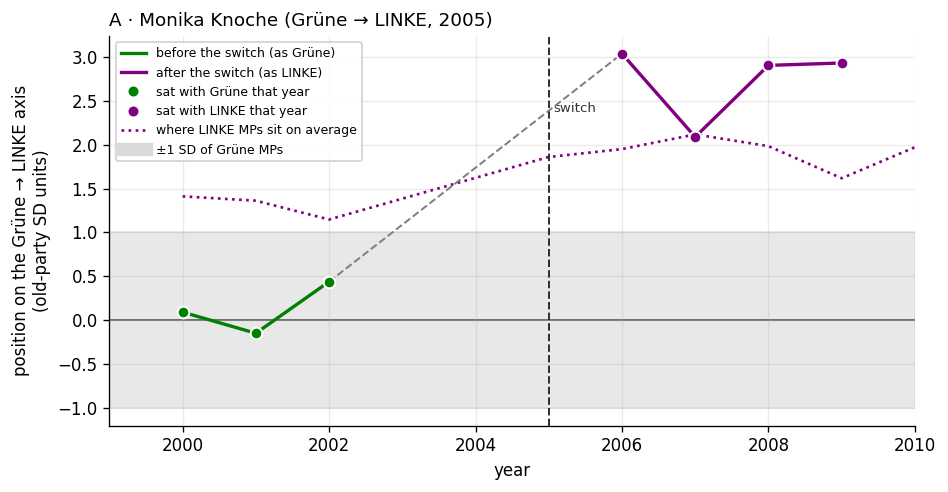

In [8]:
def plot_case(g, anch, case, old_label, new_label, ax=None):
    ax = ax or plt.subplots(figsize=(8, 4.2))[1]
    yrs = g.year.to_numpy()

    # the old party's sd is 1 by construction, so the grey band is simply -1 to +1
    ax.axhspan(-1, 1, color="0.85", alpha=.6, zorder=0)
    ax.axhline(0, color="0.35", lw=1, zorder=1)
    a = anch.dropna(subset=["z_new"])
    ax.plot(a.year, a.z_new, color=PARTY_COLORS.get(case["new"], "grey"),
            ls=":", lw=1.6, zorder=2)

    ax.axvline(case["switch"], color="0.2", ls="--", lw=1.2, zorder=2)
    ax.annotate("switch", (case["switch"], ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    pre, post = g[g.year < case["switch"]], g[g.year >= case["switch"]]
    for part, c in [(pre, PARTY_COLORS.get(case["old"], "grey")),
                    (post, PARTY_COLORS.get(case["new"], "grey"))]:
        ax.plot(part.year, part.z, "-", color=c, lw=2, zorder=4)
    if len(pre) and len(post):
        ax.plot([pre.year.iloc[-1], post.year.iloc[0]], [pre.z.iloc[-1], post.z.iloc[0]],
                color="0.5", lw=1.2, ls="--", zorder=3)

    # markers take the colour of the party the MP actually sat with that year, otherwise the
    # independent years get painted as the old party and the plot quietly misleads
    seen = []
    for _, r in g.iterrows():
        p = str(r.party).replace("LINKE-bloc", "LINKE")
        ax.plot(r.year, r.z, "o", ms=7, zorder=5, color=PARTY_COLORS.get(p, "grey"),
                mec="white", mew=1.2)
        if p not in seen:
            seen.append(p)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))

    ax.set_xlim(yrs.min() - 1, yrs.max() + 1)
    ax.set_xlabel("year")
    ax.set_ylabel(f"position on the {old_label} → {new_label} axis\n(old-party SD units)")
    ax.set_title(case["label"], loc="left", fontsize=11)
    ax.legend(handles=[
        Line2D([], [], color=PARTY_COLORS.get(case["old"], "grey"), lw=2,
               label=f"before the switch (as {old_label})"),
        Line2D([], [], color=PARTY_COLORS.get(case["new"], "grey"), lw=2,
               label=f"after the switch (as {new_label})"),
        *[Line2D([], [], color=PARTY_COLORS.get(p, "grey"), marker="o", ls="", ms=7,
                 mec="white", label=f"sat with {p} that year") for p in seen],
        Line2D([], [], color=PARTY_COLORS.get(case["new"], "grey"), ls=":", lw=1.6,
               label=f"where {new_label} MPs sit on average"),
        Line2D([], [], color="0.85", lw=8, label=f"±1 SD of {old_label} MPs"),
    ], fontsize=7.5, loc="best", framealpha=.9)
    return ax

fig, ax = plt.subplots(figsize=(8, 4.2))
plot_case(g_knoche, anch_knoche, knoche, "Grüne", "LINKE", ax=ax)
plt.tight_layout(); plt.savefig("fig_case_A.png", dpi=150, bbox_inches="tight"); plt.show()

Knoche is an ordinary Green while she sits for the party — 0.09, −0.15 and 0.44, all inside the
±1 SD band — and at 2.1 to 3.0 afterwards, above the dotted LINKE average in three of her four
years. So she does not merely reach her new party's position, she mostly passes it. Nothing
moves beforehand: her final Green year is the highest of the three but still unremarkable for a
Green. The dashed segment covers 2003–2005, when she was not in parliament, so it interpolates
across a gap rather than tracing a drift.

## 5. Hohmann — CDU/CSU → AfD

This MP left the CDU/CSU Fraktion in 2003, sat briefly as an independent, then disappeared
from parliament for more than a decade and returned in 2017 for the AfD. The corpus holds no
speeches from him between mid-2003 and 2005, which is why the table above dates the transition
to 2005 rather than to the expulsion. The gap is an obvious problem: a different parliament, a
different agenda, a different decade of language. Recomputing $z$ every year is what makes the
comparison possible at all, since the MP is always measured against the CDU/CSU of that
particular year rather than against some fixed reference.

 year        party  n_speeches        z    z_new  n_old  n_new
 2000      CDU/CSU           2 0.009472      NaN    213      0
 2001      CDU/CSU           4 1.315006      NaN    200      0
 2002      CDU/CSU           1 1.350855      NaN    212      0
 2003      CDU/CSU           8 1.012321      NaN    228      0
 2005 Fraktionslos           2 3.251971      NaN    203      0
 2018          AfD           9 2.916416 2.195137    209     89
 2019          AfD           4 3.056567 2.213721    213     88
 2020          AfD           7 2.485140 2.077795    204     85


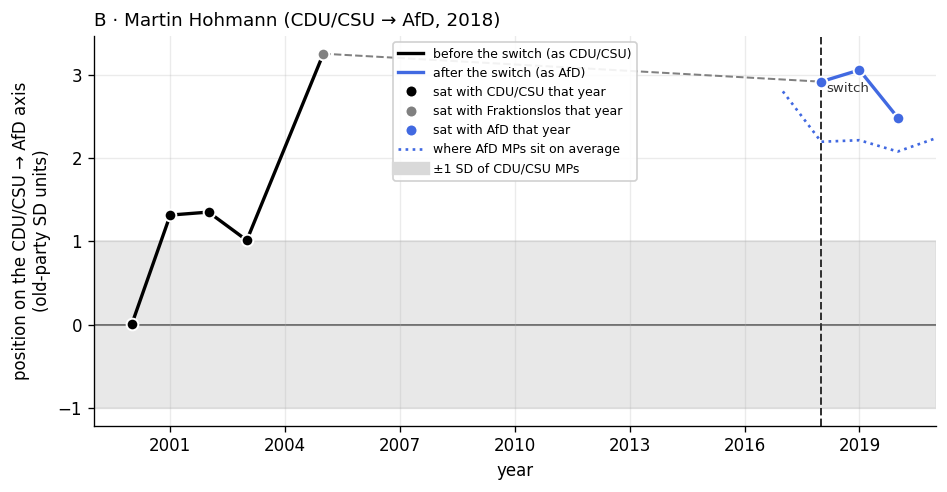

In [9]:
hohmann = CASES[1]
# min_speeches=1 here, otherwise the CDU years (1-8 speeches each) vanish and there is
# nothing left to compare the AfD years against
g_hohmann, anch_hohmann = trajectory(mpd, hohmann["pid"], "CDU/CSU", "AfD", min_speeches=1)
print(g_hohmann[["year", "party", "n_speeches", "z", "z_new", "n_old", "n_new"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.2))
plot_case(g_hohmann, anch_hohmann, hohmann, "CDU/CSU", "AfD", ax=ax)
plt.tight_layout(); plt.savefig("fig_case_B.png", dpi=150, bbox_inches="tight"); plt.show()

Hohmann starts indistinguishable from the CDU/CSU average (0.01 in 2000) and sits at 1.0–1.35
from 2001, just outside his party's band — though those years rest on one to eight speeches, so
the level is better evidence than the trend. As an AfD member he is at 2.49–3.06, above the AfD
average of roughly 2.1. The dashed segment spans thirteen years out of parliament, so the step
across it is not a measured movement.

## 6. Was change bigger than usual?

In [10]:
def window_mean(g, years):
    "Speech-weighted mean vector over a set of years, plus how many speeches went into it."
    g = g[g.year.isin(years)]
    if g.empty:
        return None, 0
    # weight by speeches so a 30-speech year counts more than a 2-speech one. Ed is already
    # year-demeaned, so the era effect is out of these vectors before we average them.
    w = g.n_speeches.to_numpy(dtype="float32")
    return np.average(np.stack(g.Ed.to_numpy()), axis=0, weights=w), int(w.sum())


def displacement_test(pid, pre_years, post_years, control_party=None, min_speeches=5):
    """Pre-vs-post cosine distance for one MP, ranked against non-switching MPs.

    The distance on its own means nothing - MPs move for all sorts of reasons. What makes it
    interpretable is the rank: how far did this MP travel compared with colleagues who lived
    through the same years and did not switch?
    """
    a, na = window_mean(mpd[mpd.politicianId == pid], pre_years)
    b, nb = window_mean(mpd[mpd.politicianId == pid], post_years)
    if a is None or b is None:
        return None
    d = 1 - cos(a, b)                      # cosine distance: 0 = identical, larger = moved

    # Controls run over the same windows, so era and agenda are shared with the switcher and
    # drop out of the comparison. Every known switcher is excluded, including the placebo
    # group, otherwise the null would be partly built from the effect we are testing for.
    pool = mpd if control_party is None else mpd[mpd.party == control_party]
    pool = pool[~pool.politicianId.isin(SWITCHERS)]
    ctrl = []
    for cid, g in pool.groupby("politicianId"):
        ca, cna = window_mean(g, pre_years)
        cb, cnb = window_mean(g, post_years)
        # a control needs speech in BOTH windows, and enough of it: section 7 shows sparse
        # MPs drift further for purely statistical reasons, which would inflate the null.
        # Note this floor applies to controls only - the switcher enters regardless, so a
        # thinly observed case (Tauss has 3 post-switch speeches) is ranked against a
        # better-observed pool and its percentile is, if anything, flattered.
        if ca is None or cb is None or min(cna, cnb) < min_speeches:
            continue
        ctrl.append(dict(politicianId=cid, dist=1 - cos(ca, cb), n_min=min(cna, cnb)))
    ctrl = pd.DataFrame(ctrl)
    if ctrl.empty:
        return dict(dist=d, n_pre=na, n_post=nb, n_ctrl=0)
    # percentile = share of controls that moved LESS than this MP; z = the same comparison in
    # sd units. _ctrl keeps the control distribution for section 7; the leading underscore is
    # what the caller strips out before printing.
    return dict(dist=d, n_pre=na, n_post=nb, n_ctrl=len(ctrl),
                ctrl_median=ctrl.dist.median(), percentile=(ctrl.dist < d).mean(),
                z=(d - ctrl.dist.mean()) / ctrl.dist.std(), _ctrl=ctrl)


# Two control scopes per case. "same party" is the tighter comparison but leaves few controls
# (19 for Knoche), "all MPs" trades that specificity for a much larger null. Agreement between
# the two is a sign the ranking is not an artefact of who happened to qualify.
rows = []
for c in CASES:
    for scope, cp in [("same party", c["old"]), ("all MPs", None)]:
        r = displacement_test(c["pid"], c["pre"], c["post"], cp)
        if r and r.get("n_ctrl"):
            rows.append(dict(case=c["label"], controls=scope,
                             **{k: v for k, v in r.items() if not k.startswith("_")}))
res = pd.DataFrame(rows)
print(res[["case", "controls", "dist", "n_pre", "n_post", "n_ctrl",
           "ctrl_median", "percentile", "z"]].to_string(index=False))

                                            case   controls     dist  n_pre  n_post  n_ctrl  ctrl_median  percentile        z
         A · Monika Knoche (Grüne → LINKE, 2005) same party 0.700072     27      54      19     0.352215    0.947368 1.679090
         A · Monika Knoche (Grüne → LINKE, 2005)    all MPs 0.700072     27      54     187     0.339704    0.839572 1.167152
        B · Martin Hohmann (CDU/CSU → AfD, 2018) same party 0.768785     15      20      20     0.775902    0.500000 0.060766
        B · Martin Hohmann (CDU/CSU → AfD, 2018)    all MPs 0.768785     15      20      46     0.651304    0.586957 0.334281
        C · Jörg Tauss (SPD → independent, 2009) same party 0.481303     71      13      53     0.216387    0.962264 1.793117
        C · Jörg Tauss (SPD → independent, 2009)    all MPs 0.481303     71      13     227     0.202527    0.920705 1.458737
D · Henry Nitzsche (CDU/CSU → independent, 2007) same party 1.040297      8       7     116     0.347345    0.982759 2

Four of the five moved further than 89–98% of their same-party colleagues over the same years,
and the two control scopes agree within a few points — except for Knoche, whose Green pool has
only 19 members.

Hohmann is the exception at the 50th percentile, and the reason is in the `ctrl_median` column:
0.78 against 0.22–0.35 everywhere else. His windows are fifteen years apart, so every control in
that comparison also had a decade and a half to change. Distance alone cannot separate a
defection from a long career, which is what sections 4 and 5 are for.

In [11]:
# Same test on the placebo group: label changed, politics did not. The windows are fixed here
# because all of these MPs share the same 2002-05 gap.
placebo_rows = []
for pid in PLACEBO:
    r = displacement_test(pid, [2000, 2001, 2002], [2006, 2007, 2008, 2009])
    if r and r.get("n_ctrl"):
        placebo_rows.append(dict(politicianId=pid,
                                 **{k: v for k, v in r.items() if not k.startswith("_")}))
plac = pd.DataFrame(placebo_rows)
print("PLACEBO - party label changed (PDS -> LINKE), no defection:\n")
print(plac[["politicianId", "dist", "n_pre", "n_post", "ctrl_median",
            "percentile", "z"]].to_string(index=False))
print(f"\nplacebo median percentile : {plac.percentile.median():.2f}   (n = {len(plac)})")
print(f"defection median percentile: "
      f"{res[res.controls == 'all MPs'].percentile.median():.2f}   "
      f"(n = {res.controls.eq('all MPs').sum()})")

PLACEBO - party label changed (PDS -> LINKE), no defection:

 politicianId     dist  n_pre  n_post  ctrl_median  percentile         z
     11000756 0.478104     38     108     0.339704    0.631016  0.265762
     11000921 0.234852     52     140     0.339704    0.336898 -0.722057
     11001023 0.161690     39      61     0.339704    0.122995 -1.019161
     11002153 0.098314    116      97     0.339704    0.026738 -1.276522
     11002636 0.107967     58      81     0.339704    0.037433 -1.237323
     11003034 0.869969      5       4     0.339704    0.946524  1.857085
     11003065 0.847056     50      44     0.339704    0.946524  1.764036
     11003130 0.060094     82     119     0.339704    0.005348 -1.431728
     11003174 0.301233     12      24     0.339704    0.433155 -0.452491
     11003197 1.048958     28       4     0.339704    0.989305  2.583939
     11003206 0.370440     45      69     0.339704    0.529412 -0.171449
     11003584 0.598928     13     100     0.339704    0.759358 

The merger MPs sit at a median 48th percentile, four of them below the 15th. Their party label
changed in exactly the way a defector's does, and they show no excess movement — so the test is
responding to the defection, not to the relabeling.

Three do land above the 94th percentile. Two rest on four speeches in one window, which section
7 explains; the third has 50 and 44 speeches and we cannot account for it. One unexplained false
positive in twelve is the error rate to quote for this design.

## 7. How much movement is just noise?

         median  count
n_min                 
≤5     0.239084     39
6-10   0.227743    117
11-20  0.139817     57
21-50  0.127914     14

corr(distance, 1/sqrt(speeches)) = +0.247


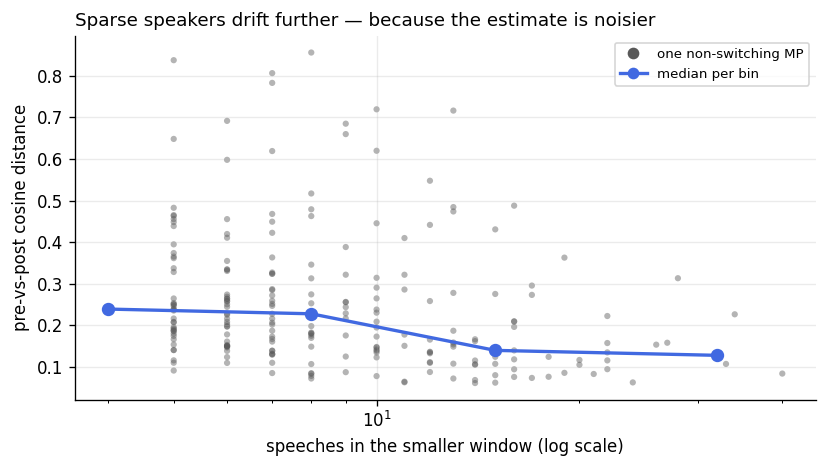

In [12]:
ctrl = displacement_test(CASES[2]["pid"], CASES[2]["pre"], CASES[2]["post"])["_ctrl"]
bins = pd.cut(ctrl.n_min, [0, 5, 10, 20, 50, 10_000],
              labels=["≤5", "6-10", "11-20", "21-50", ">50"])
tab = ctrl.groupby(bins, observed=True).dist.agg(["median", "count"])
tab = tab[tab["count"] > 0]
print(tab.to_string())
print(f"\ncorr(distance, 1/sqrt(speeches)) = {ctrl.dist.corr(1 / np.sqrt(ctrl.n_min)):+.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(ctrl.n_min, ctrl.dist, s=14, alpha=.45, color="0.35", edgecolor="none")
centres = {"≤5": 4, "6-10": 8, "11-20": 15, "21-50": 32, ">50": 70}   # log-scale bin centres
ax.plot([centres[str(s)] for s in tab.index], tab["median"], "-o", color="royalblue", lw=2, ms=7)
ax.set_xscale("log"); ax.set_xlabel("speeches in the smaller window (log scale)")
ax.set_ylabel("pre-vs-post cosine distance")
ax.set_title("Sparse speakers drift further — because the estimate is noisier",
             loc="left", fontsize=11)
ax.legend(handles=[Line2D([], [], color="0.35", marker="o", ls="", label="one non-switching MP"),
                   Line2D([], [], color="royalblue", marker="o", lw=2, label="median per bin")],
          fontsize=8)
plt.tight_layout(); plt.savefig("fig_noise.png", dpi=150, bbox_inches="tight"); plt.show()

Among MPs who never switched, the fewer speeches behind a window, the further apart their two
window vectors appear: median 0.24 at five or fewer speeches against 0.13 above twenty,
correlating +0.25 with 1/√n. Sparse cells are noisy estimates, so part of any measured movement
is estimation error rather than political change. That is why cells below three speeches are
dropped, and why the two placebo MPs above the 94th percentile both rest on four speeches.

## 8. Summary

In [13]:
# One row per case. Two numbers describe each: how far the MP moved between the two windows
# (section 6), and - where an axis exists - where they sat on it before and after (sections 4
# and 5). Cases ending at Fraktionslos have no axis, so those columns stay empty.
summary = []
for c in CASES:
    same = displacement_test(c["pid"], c["pre"], c["post"], c["old"])   # vs their own party
    allm = displacement_test(c["pid"], c["pre"], c["post"])             # vs the whole Bundestag

    z_before = z_after = np.nan
    if c["new"] != "Fraktionslos":
        src, old, new = ((mp_bloc, "Grüne", "LINKE-bloc") if c["key"] == "A"
                         else (mpd, c["old"], c["new"]))
        g, _ = trajectory(src, c["pid"], old, new, min_speeches=1)
        # average only over the years they actually sat with each party, so the independent
        # interlude does not get counted as part of either side
        # weighted by speeches, otherwise a 1-speech year (Knoche 2005) dominates the mean
        gp = g[g.party == old]; z_before = np.average(gp.z, weights=gp.n_speeches)
        gp = g[g.party == new]; z_after  = np.average(gp.z, weights=gp.n_speeches)

    summary.append(dict(case=c["name"], n_pre=same["n_pre"], n_post=same["n_post"],
                        pct_own_party=same["percentile"], pct_all_MPs=allm["percentile"],
                        z_before=z_before, z_after=z_after))

s = pd.DataFrame(summary)
# a switch counts as detected by distance if the MP moved further than 90% of colleagues from
# the same party over the same years
s["moved_more_than_peers"] = np.where(s.pct_own_party >= 0.90, "yes", "no")

print(s.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print(f"\nplacebo group (label changed, no defection): median percentile "
      f"{plac.percentile.median():.2f} across {len(plac)} MPs")

          case  n_pre  n_post  pct_own_party  pct_all_MPs  z_before  z_after moved_more_than_peers
 Monika Knoche     27      54           0.95         0.84      0.09     2.77                   yes
Martin Hohmann     15      20           0.50         0.59      0.98     2.79                    no
    Jörg Tauss     71      13           0.96         0.92       NaN      NaN                   yes
Henry Nitzsche      8       7           0.98         0.99       NaN      NaN                   yes
    Uwe Kamann      6       6           0.89         0.89       NaN      NaN                    no

placebo group (label changed, no defection): median percentile 0.48 across 12 MPs


Knoche, Tauss and Nitzsche moved more than 90% of their party colleagues. Kamann at 0.89 is
borderline and rests on six speeches either side. Hohmann is not detected by distance at all,
yet ends around 2.8 SD outside the CDU/CSU on the anchored axis — the case where direction
matters and distance does not, and the reason the notebook uses both.

Against the placebo group's 0.48 these numbers mean something: switches are detectable, a
relabeling is not. One caveat: our windows are calendar years, but MPs defect mid-year. Tauss
left in July 2009 and his post window is the 2009 cell, which holds ten speeches from before the
switch and three from after, so his ranking is not a clean before/after contrast.